# 03 - Sentiment vs PnL Analysis
**Goal:** Deep-dive EDA on how Bitcoin market sentiment relates to trader performance. Uncover patterns, test hypotheses, and surface actionable insights.

**Questions answered:**
1. Do traders make more money during Fear or Greed?
2. Does trading volume spike at sentiment extremes?
3. Are contrarian traders more profitable?
4. Does sentiment momentum (rising/falling) affect outcomes?
5. Which trader tier benefits most from each sentiment zone?
6. Is there a lag effect-does yesterday's sentiment predict today's PnL?

**Input:** `data/processed/analysis_ready.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
SENTIMENT_ORDER  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
COLOR_MAP        = dict(zip(SENTIMENT_ORDER, SENTIMENT_COLORS))

PROCESSED_DIR = '../data/processed/'
INPUT_FILE    = os.path.join(PROCESSED_DIR, 'analysis_ready.csv')
PROFILE_FILE  = os.path.join(PROCESSED_DIR, 'account_profiles.csv')

In [5]:
df = pd.read_csv(INPUT_FILE, parse_dates=['date'])
ap = pd.read_csv(PROFILE_FILE)


# Fix collision if present
if 'trader_tier_x' in df.columns:
    df.rename(columns={'trader_tier_x': 'trader_tier'}, inplace=True)
    df.drop(columns=['trader_tier_y'], errors='ignore', inplace=True)

# Restore ordered categories
df['fg_label']    = pd.Categorical(df['fg_label'],    categories=SENTIMENT_ORDER, ordered=True)
df['trader_tier'] = pd.Categorical(df['trader_tier'], categories=['Losing','Break-even','Profitable'], ordered=True)

print(f'Main df  : {df.shape}')
print(f'Profiles : {ap.shape}')
df.head(3)

Main df  : (2340, 38)
Profiles : (32, 13)


,account,date,total_pnl,total_volume,total_fee,trade_count,buy_count,sell_count,avg_exec_price,coins_traded,...,is_contrarian,log_volume,pnl_tier,trader_tier,acct_win_rate_x,acct_contrarian_rate_x,acct_pnl_per_trade_x,acct_win_rate_y,acct_contrarian_rate_y,acct_pnl_per_trade_y
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,167.796055,177,0,177,3204.461017,1,...,1,13.711129,Bottom 25%,Profitable,0.6667,0.375,417.1882,0.6667,0.375,417.1882
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,67.883615,68,0,68,653.365147,2,...,1,13.203785,Bottom 25%,Profitable,0.6667,0.375,417.1882,0.6667,0.375,417.1882
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,94.937983,40,0,40,3164.600000,1,...,1,13.763565,Bottom 25%,Profitable,0.6667,0.375,417.1882,0.6667,0.375,417.1882


## Q1 - Do Traders Profit More During Fear or Greed?

In [6]:
pnl_by_sentiment = (
    df.groupby('fg_label', observed=True)
    .agg(
        median_pnl  = ('net_pnl_w', 'median'),
        mean_pnl    = ('net_pnl_w', 'mean'),
        total_pnl   = ('net_pnl',   'sum'),
        win_rate    = ('is_win',     'mean'),
        n_rows      = ('net_pnl',   'count')
    )
    .reset_index()
)
pnl_by_sentiment['win_rate_pct'] = (pnl_by_sentiment['win_rate'] * 100).round(1)
print(pnl_by_sentiment.to_string(index=False))

     fg_label  median_pnl    mean_pnl    total_pnl  win_rate  n_rows  win_rate_pct
 Extreme Fear  162.641338 4711.694832 7.152216e+05  0.581250     160          58.1
         Fear   97.091622 3901.297763 3.264698e+06  0.595238     630          59.5
      Neutral  151.366218 3397.656752 1.253546e+06  0.622340     376          62.2
        Greed  140.232394 3173.835560 2.087031e+06  0.598765     648          59.9
Extreme Greed  362.828922 4236.503170 2.688141e+06  0.678707     526          67.9


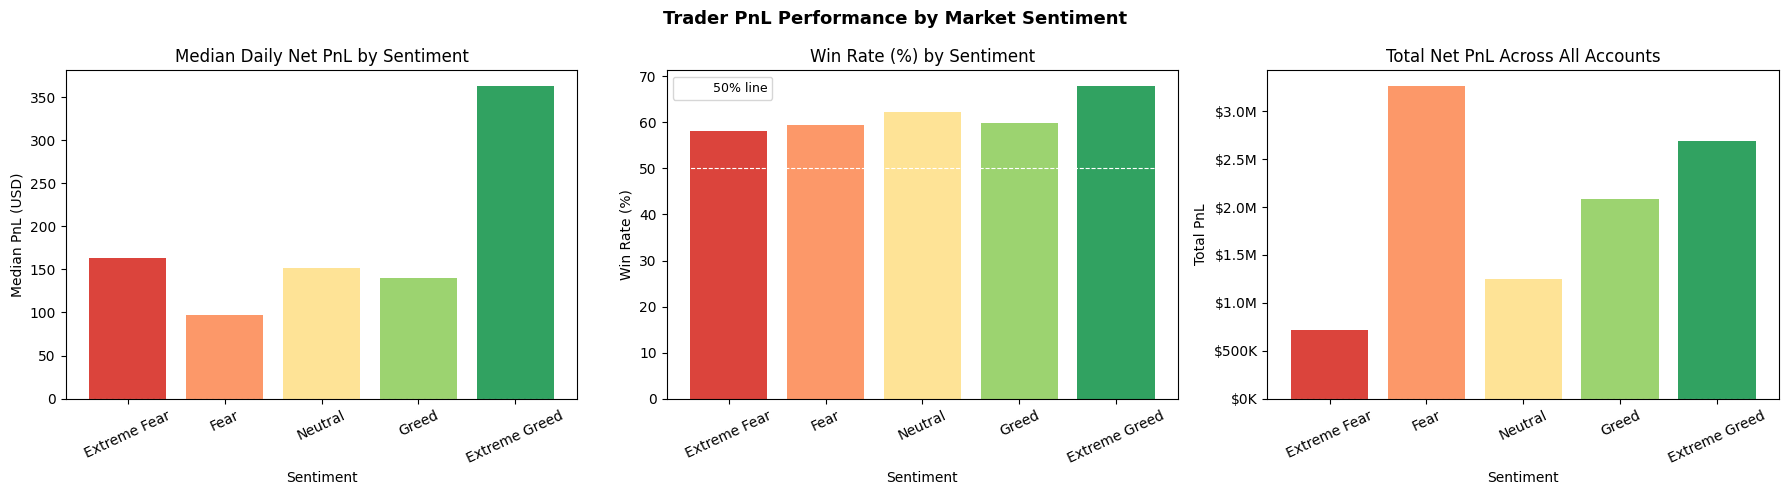

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Median PnL
colors = [COLOR_MAP[l] for l in pnl_by_sentiment['fg_label']]
axes[0].bar(pnl_by_sentiment['fg_label'], pnl_by_sentiment['median_pnl'],
            color=colors, edgecolor='none', alpha=0.9)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[0].set(title='Median Daily Net PnL by Sentiment',
            xlabel='Sentiment', ylabel='Median PnL (USD)')
axes[0].tick_params(axis='x', rotation=25)

# Win Rate
axes[1].bar(pnl_by_sentiment['fg_label'], pnl_by_sentiment['win_rate_pct'],
            color=colors, edgecolor='none', alpha=0.9)
axes[1].axhline(50, color='white', linewidth=0.8, linestyle='--', label='50% line')
axes[1].set(title='Win Rate (%) by Sentiment',
            xlabel='Sentiment', ylabel='Win Rate (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=9)

# Total PnL
axes[2].bar(pnl_by_sentiment['fg_label'], pnl_by_sentiment['total_pnl'],
            color=colors, edgecolor='none', alpha=0.9)
axes[2].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M' if abs(x) >= 1e6 else f'${x/1e3:.0f}K'
))
axes[2].set(title='Total Net PnL Across All Accounts',
            xlabel='Sentiment', ylabel='Total PnL')
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Trader PnL Performance by Market Sentiment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
##  Q2 - Does Trading Volume Spike at Sentiment Extremes?

In [8]:
vol_by_sentiment = (
    df.groupby('fg_label', observed=True)
    .agg(
        median_volume = ('total_volume_w', 'median'),
        mean_volume   = ('total_volume_w', 'mean'),
        median_trades = ('trade_count',    'median'),
    )
    .reset_index()
)
print(vol_by_sentiment.to_string(index=False))

     fg_label  median_volume   mean_volume  median_trades
 Extreme Fear     128229.925 715526.634000           50.5
         Fear      69699.270 506381.905594           26.0
      Neutral      75725.155 385311.918189           29.5
        Greed      61186.925 332382.964425           25.0
Extreme Greed      61028.670 236625.796941           31.5


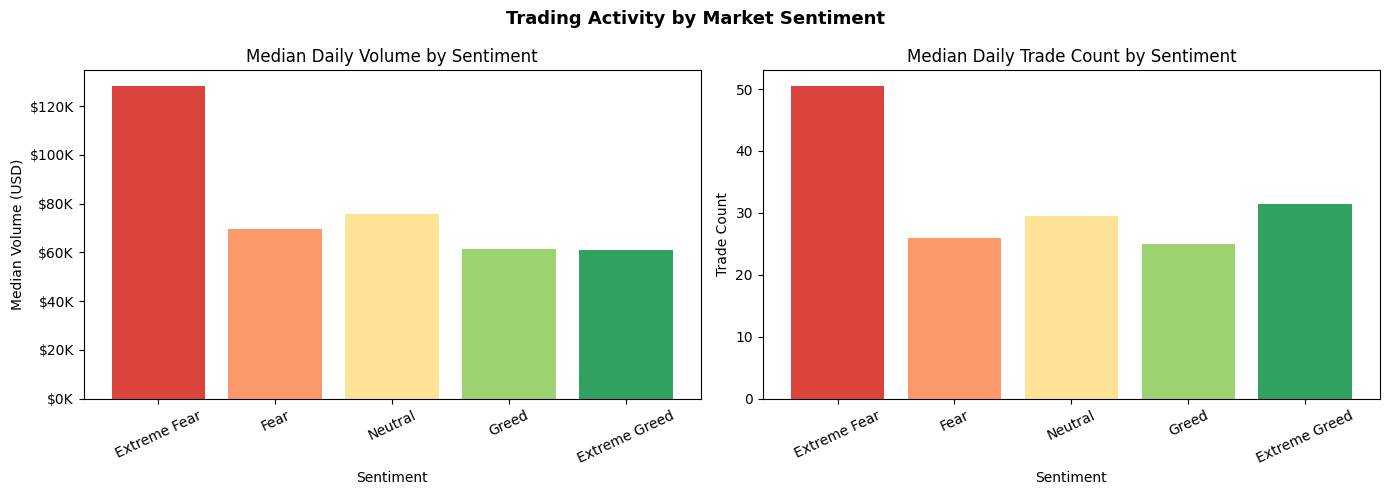

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [COLOR_MAP[l] for l in vol_by_sentiment['fg_label']]

# Volume
axes[0].bar(vol_by_sentiment['fg_label'], vol_by_sentiment['median_volume'],
            color=colors, edgecolor='none', alpha=0.9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e3:.0f}K'
))
axes[0].set(title='Median Daily Volume by Sentiment',
            xlabel='Sentiment', ylabel='Median Volume (USD)')
axes[0].tick_params(axis='x', rotation=25)

# Trade count 
axes[1].bar(vol_by_sentiment['fg_label'], vol_by_sentiment['median_trades'],
            color=colors, edgecolor='none', alpha=0.9)
axes[1].set(title='Median Daily Trade Count by Sentiment',
            xlabel='Sentiment', ylabel='Trade Count')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Trading Activity by Market Sentiment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

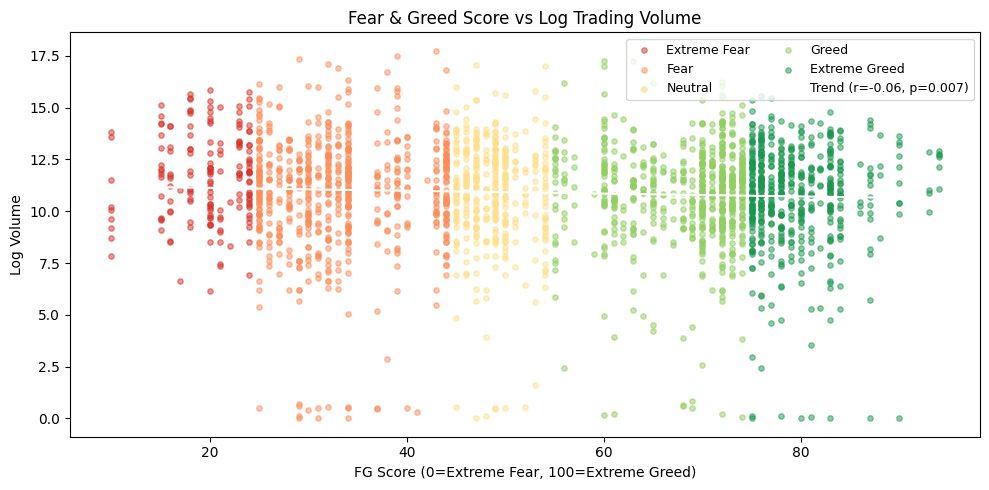

In [10]:
#  FG score vs log volume scatter
fig, ax = plt.subplots(figsize=(10, 5))

for label in SENTIMENT_ORDER:
    sub = df[df['fg_label'] == label]
    ax.scatter(sub['fg_value'], sub['log_volume'],
               color=COLOR_MAP[label], label=label, s=15, alpha=0.5)

# Regression line
x = df['fg_value'].dropna()
y = df.loc[x.index, 'log_volume'].dropna()
common = x.index.intersection(y.index)
m, b, r, p, _ = stats.linregress(x[common], y[common])
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, color='white', linewidth=1.5,
        label=f'Trend (r={r:.2f}, p={p:.3f})')

ax.set(title='Fear & Greed Score vs Log Trading Volume',
       xlabel='FG Score (0=Extreme Fear, 100=Extreme Greed)',
       ylabel='Log Volume')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

##  Q3 -Are Contrarian Traders More Profitable?

In [11]:
contrarian_summary = (
    df.groupby('is_contrarian')
    .agg(
        median_pnl = ('net_pnl_w', 'median'),
        mean_pnl   = ('net_pnl_w', 'mean'),
        win_rate   = ('is_win',     'mean'),
        count      = ('net_pnl',   'count')
    )
    .reset_index()
)
contrarian_summary['label'] = contrarian_summary['is_contrarian'].map(
    {0: 'Trend-Following', 1: 'Contrarian'}
)
print(contrarian_summary[['label','median_pnl','mean_pnl','win_rate','count']].to_string(index=False))

          label  median_pnl    mean_pnl  win_rate  count
Trend-Following  193.143146 3348.163233  0.635565   1479
     Contrarian  136.863628 4439.396506  0.588850    861


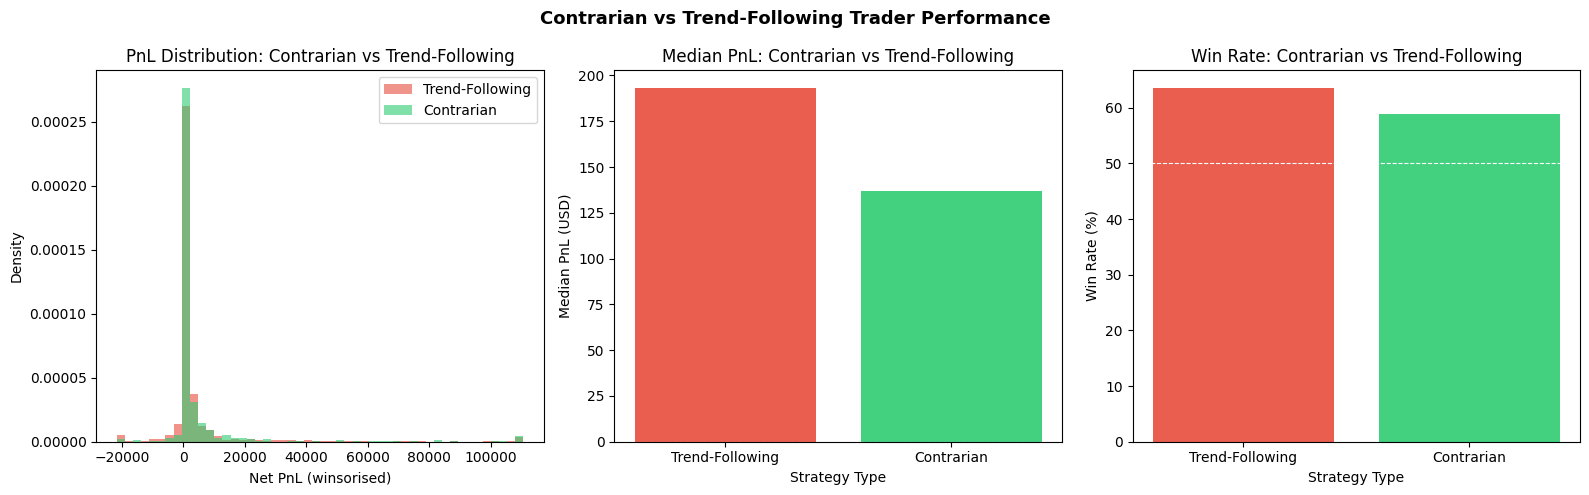

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {0: '#e74c3c', 1: '#2ecc71'}

#  KDE of PnL by contrarian flag 
for flag, label in [(0, 'Trend-Following'), (1, 'Contrarian')]:
    sub = df[df['is_contrarian'] == flag]['net_pnl_w'].dropna()
    axes[0].hist(sub, bins=50, alpha=0.6, color=palette[flag],
                 label=label, density=True)
axes[0].set(title='PnL Distribution: Contrarian vs Trend-Following',
            xlabel='Net PnL (winsorised)', ylabel='Density')
axes[0].legend()

#  Median PnL bar 
axes[1].bar(contrarian_summary['label'], contrarian_summary['median_pnl'],
            color=[palette[i] for i in contrarian_summary['is_contrarian']],
            edgecolor='none', alpha=0.9)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set(title='Median PnL: Contrarian vs Trend-Following',
            xlabel='Strategy Type', ylabel='Median PnL (USD)')

#  Win Rate bar
axes[2].bar(contrarian_summary['label'],
            contrarian_summary['win_rate'] * 100,
            color=[palette[i] for i in contrarian_summary['is_contrarian']],
            edgecolor='none', alpha=0.9)
axes[2].axhline(50, color='white', linewidth=0.8, linestyle='--')
axes[2].set(title='Win Rate: Contrarian vs Trend-Following',
            xlabel='Strategy Type', ylabel='Win Rate (%)')

plt.suptitle('Contrarian vs Trend-Following Trader Performance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

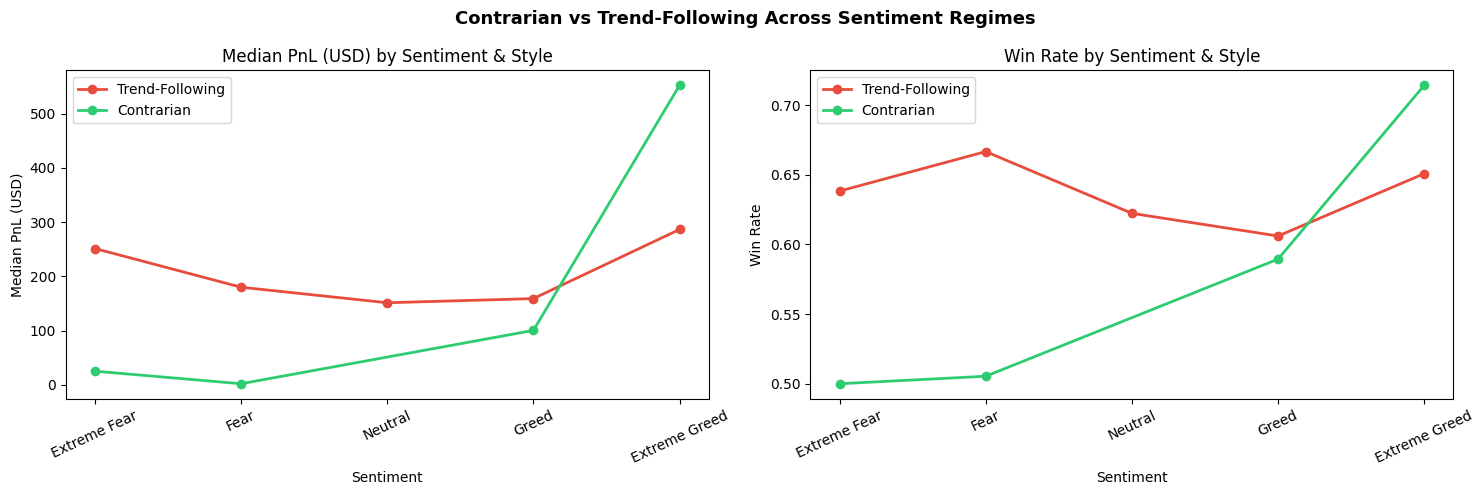

In [13]:
#  Contrarian performance broken down by sentiment
ct = (
    df.groupby(['fg_label', 'is_contrarian'], observed=True)
    .agg(median_pnl=('net_pnl_w', 'median'), win_rate=('is_win', 'mean'))
    .reset_index()
)
ct['style'] = ct['is_contrarian'].map({0: 'Trend-Following', 1: 'Contrarian'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, ylabel in zip(
    axes,
    ['median_pnl', 'win_rate'],
    ['Median PnL (USD)', 'Win Rate']
):
    for style, color in [('Trend-Following', '#e74c3c'), ('Contrarian', '#2ecc71')]:
        sub = ct[ct['style'] == style]
        ax.plot(sub['fg_label'].astype(str), sub[metric],
                marker='o', label=style, color=color, linewidth=2)
    ax.set(title=f'{ylabel} by Sentiment & Style',
           xlabel='Sentiment', ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend()

plt.suptitle('Contrarian vs Trend-Following Across Sentiment Regimes',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Q4 - Does Sentiment Momentum Affect Outcomes?

In [14]:
momentum_map = {-1.0: 'Falling (↓)', 0.0: 'Flat (→)', 1.0: 'Rising (↑)'}
df['momentum_label'] = df['fg_momentum'].map(momentum_map)

mom_summary = (
    df.groupby('momentum_label')
    .agg(
        median_pnl = ('net_pnl_w', 'median'),
        win_rate   = ('is_win',     'mean'),
        count      = ('net_pnl',   'count')
    )
    .reset_index()
)
print(mom_summary.to_string(index=False))

momentum_label  median_pnl  win_rate  count
   Falling (↓)  146.422423  0.599656   1164
      Flat (→)  157.069879  0.595238     84
    Rising (↑)  218.276412  0.640110   1092


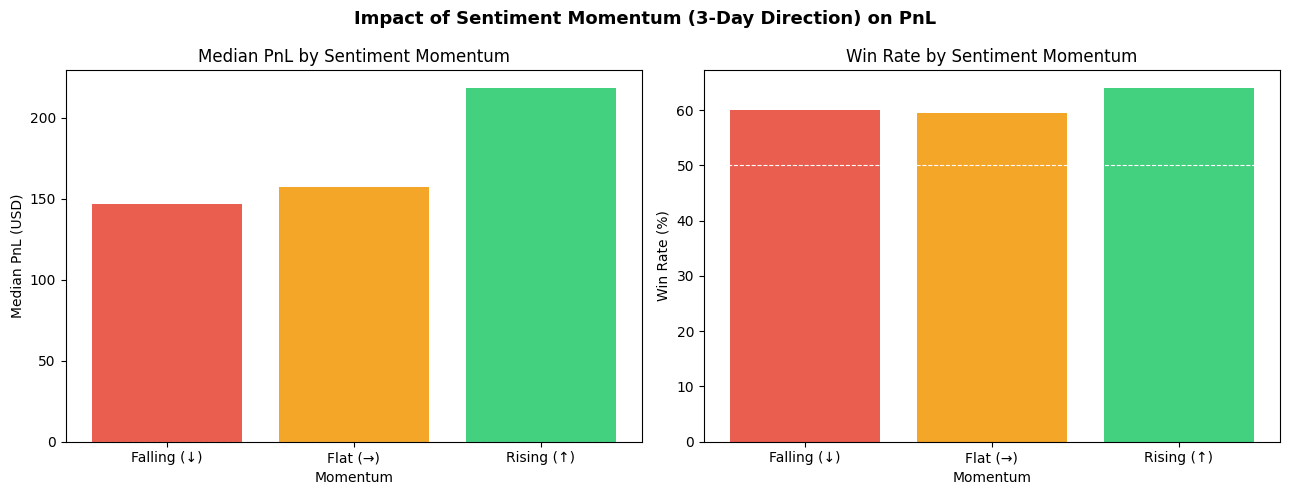

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mom_colors = {'Falling (↓)': '#e74c3c', 'Flat (→)': '#f39c12', 'Rising (↑)': '#2ecc71'}
bar_colors = [mom_colors.get(l, 'grey') for l in mom_summary['momentum_label']]

axes[0].bar(mom_summary['momentum_label'], mom_summary['median_pnl'],
            color=bar_colors, edgecolor='none', alpha=0.9)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[0].set(title='Median PnL by Sentiment Momentum',
            xlabel='Momentum', ylabel='Median PnL (USD)')

axes[1].bar(mom_summary['momentum_label'],
            mom_summary['win_rate'] * 100,
            color=bar_colors, edgecolor='none', alpha=0.9)
axes[1].axhline(50, color='white', linewidth=0.8, linestyle='--')
axes[1].set(title='Win Rate by Sentiment Momentum',
            xlabel='Momentum', ylabel='Win Rate (%)')

plt.suptitle('Impact of Sentiment Momentum (3-Day Direction) on PnL',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

##  Q5- Which Trader Tier Benefits Most from Each Sentiment Zone?

In [16]:
tier_sentiment = (
    df.groupby(['trader_tier', 'fg_label'], observed=True)
    .agg(
        median_pnl = ('net_pnl_w', 'median'),
        win_rate   = ('is_win',     'mean'),
        count      = ('net_pnl',   'count')
    )
    .reset_index()
)
tier_sentiment.head(10)

,trader_tier,fg_label,median_pnl,win_rate,count
0,Losing,Extreme Fear,104.115634,0.595745,47
1,Losing,Fear,131.968312,0.598837,172
2,Losing,Neutral,31.539193,0.552083,96
3,Losing,Greed,33.303138,0.562500,144
4,Losing,Extreme Greed,45.684849,0.569106,123
5,Break-even,Extreme Fear,24.758141,0.510204,49
6,Break-even,Fear,30.600744,0.614943,174
7,Break-even,Neutral,156.119234,0.697917,96
8,Break-even,Greed,267.951842,0.750000,156
9,Break-even,Extreme Greed,429.119898,0.755952,168


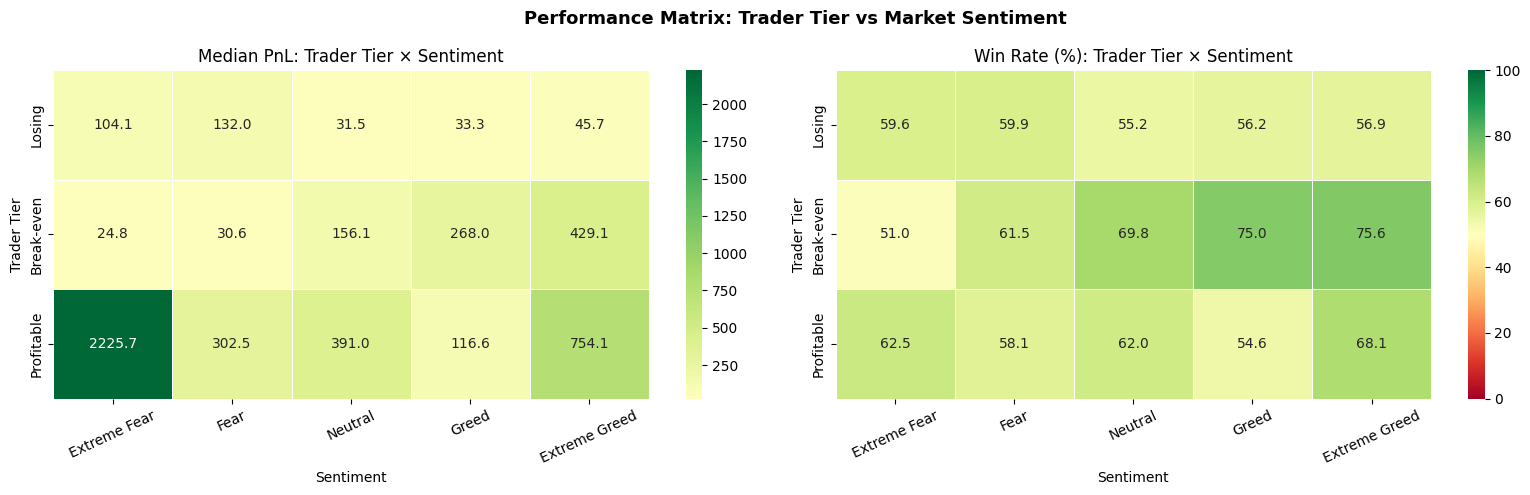

In [17]:
# Heatmap: median PnL — trader tier vs sentiment 
pivot_pnl = tier_sentiment.pivot(
    index='trader_tier', columns='fg_label', values='median_pnl'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_pnl, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set(title='Median PnL: Trader Tier × Sentiment',
            xlabel='Sentiment', ylabel='Trader Tier')
axes[0].tick_params(axis='x', rotation=25)

pivot_wr = tier_sentiment.pivot(
    index='trader_tier', columns='fg_label', values='win_rate'
) * 100
sns.heatmap(pivot_wr, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=axes[1])
axes[1].set(title='Win Rate (%): Trader Tier × Sentiment',
            xlabel='Sentiment', ylabel='Trader Tier')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Performance Matrix: Trader Tier vs Market Sentiment',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

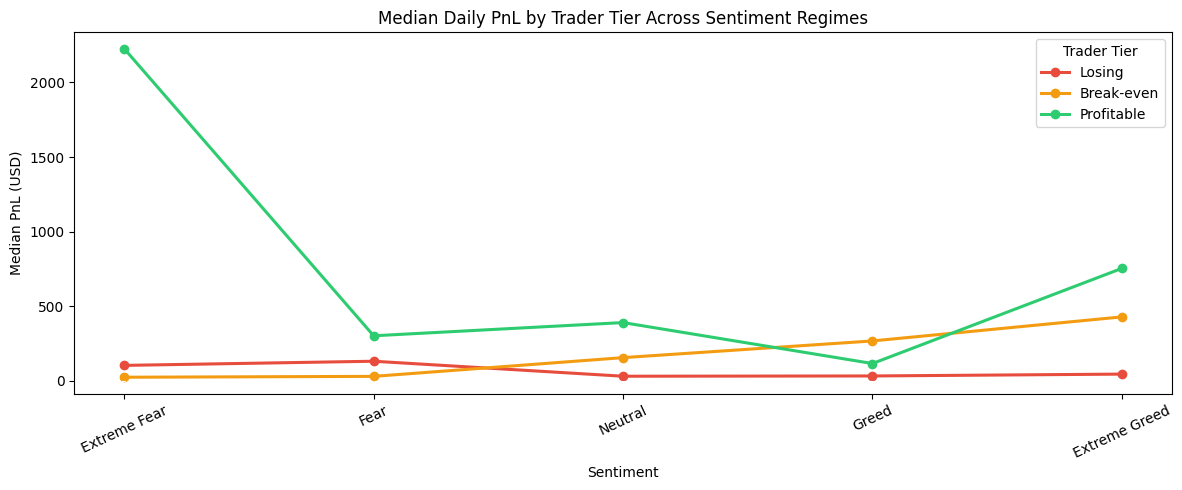

In [18]:
#  Line chart: each tier's median PnL across sentiment 
tier_colors = {'Losing': '#e74c3c', 'Break-even': '#f39c12', 'Profitable': '#2ecc71'}

fig, ax = plt.subplots(figsize=(12, 5))
for tier in ['Losing', 'Break-even', 'Profitable']:
    sub = tier_sentiment[tier_sentiment['trader_tier'] == tier]
    ax.plot(sub['fg_label'].astype(str), sub['median_pnl'],
            marker='o', label=tier, color=tier_colors[tier], linewidth=2.2)

ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax.set(title='Median Daily PnL by Trader Tier Across Sentiment Regimes',
       xlabel='Sentiment', ylabel='Median PnL (USD)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Trader Tier')
plt.tight_layout()
plt.show()

##  Q6 - Lag Effect: Does Yesterday's Sentiment Predict Today's PnL?

In [19]:
# Build a date-level daily aggregate first
daily_agg = (
    df.groupby('date')
    .agg(
        total_pnl    = ('net_pnl',    'sum'),
        median_pnl   = ('net_pnl_w',  'median'),
        total_volume = ('total_volume','sum'),
        avg_win_rate = ('is_win',      'mean'),
        fg_value     = ('fg_value',    'first'),
        fg_label     = ('fg_label',    'first'),
    )
    .reset_index()
    .sort_values('date')
)

# Create lag features
for lag in [1, 2, 3]:
    daily_agg[f'fg_lag{lag}'] = daily_agg['fg_value'].shift(lag)

daily_agg.dropna(inplace=True)
print(f'Daily agg shape: {daily_agg.shape}')
daily_agg.head(5)

Daily agg shape: (476, 10)


,date,total_pnl,median_pnl,total_volume,avg_win_rate,fg_value,fg_label,fg_lag1,fg_lag2,fg_lag3
3,2023-12-15,-27.284523,-27.284523,10609.95,0.0,70.0,Greed,72.0,75.0,63.0
4,2023-12-16,-3.837189,-3.837189,15348.77,0.0,67.0,Greed,70.0,72.0,75.0
5,2023-12-17,275.913286,275.913286,116278.02,1.0,73.0,Greed,67.0,70.0,72.0
6,2023-12-18,-7.791045,-7.791045,31164.18,0.0,65.0,Greed,73.0,67.0,70.0
7,2023-12-19,977.638016,977.638016,91602.41,1.0,73.0,Greed,65.0,73.0,67.0


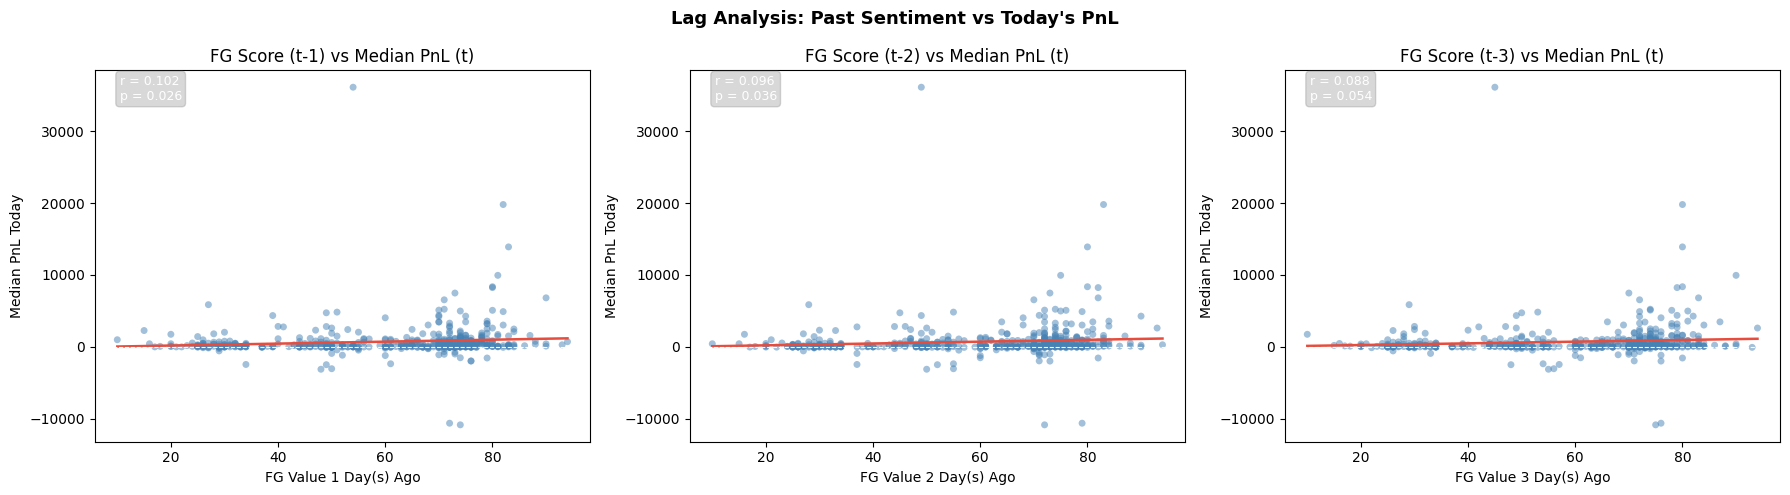

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lag in zip(axes, [1, 2, 3]):
    x = daily_agg[f'fg_lag{lag}']
    y = daily_agg['median_pnl']
    ax.scatter(x, y, alpha=0.5, s=25, color='steelblue', edgecolors='none')

    # Regression
    m, b, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color='#e74c3c', linewidth=1.8)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')

    ax.set(title=f'FG Score (t-{lag}) vs Median PnL (t)',
           xlabel=f'FG Value {lag} Day(s) Ago',
           ylabel='Median PnL Today')
    ax.text(0.05, 0.92, f'r = {r:.3f}\np = {p:.3f}',
            transform=ax.transAxes, fontsize=9,
            color='white', bbox=dict(boxstyle='round', alpha=0.3, color='grey'))

plt.suptitle('Lag Analysis: Past Sentiment vs Today\'s PnL',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


##  Key Insights Summary

In [21]:
print('=' * 60)
print('  KEY INSIGHTS-Sentiment vs Trader Performance')
print('=' * 60)

# Q1
best_sentiment = pnl_by_sentiment.loc[pnl_by_sentiment['median_pnl'].idxmax(), 'fg_label']
best_wr        = pnl_by_sentiment.loc[pnl_by_sentiment['win_rate'].idxmax(), 'fg_label']
print(f'\n[Q1] Best median PnL sentiment  : {best_sentiment}')
print(f'     Highest win rate sentiment  : {best_wr}')

# Q2
high_vol = vol_by_sentiment.loc[vol_by_sentiment['median_volume'].idxmax(), 'fg_label']
print(f'\n[Q2] Highest volume sentiment    : {high_vol}')

# Q3
c_pnl  = contrarian_summary.loc[contrarian_summary['is_contrarian']==1, 'median_pnl'].values[0]
tf_pnl = contrarian_summary.loc[contrarian_summary['is_contrarian']==0, 'median_pnl'].values[0]
print(f'\n[Q3] Contrarian median PnL       : {c_pnl:.2f}')
print(f'     Trend-following median PnL   : {tf_pnl:.2f}')
print(f'     Contrarian edge              : {"YES" if c_pnl > tf_pnl else "NO"}')

# Q4
best_mom = mom_summary.loc[mom_summary['median_pnl'].idxmax(), 'momentum_label']
print(f'\n[Q4] Best PnL momentum regime    : {best_mom}')

# Q6
lag_corrs = {
    lag: stats.pearsonr(daily_agg[f'fg_lag{lag}'], daily_agg['median_pnl'])[0]
    for lag in [1, 2, 3]
}
best_lag = max(lag_corrs, key=lambda k: abs(lag_corrs[k]))
print(f'\n[Q6] Strongest lag correlation   : t-{best_lag} day(s) (r={lag_corrs[best_lag]:.3f})')
print('\n' + '=' * 60)

  KEY INSIGHTS-Sentiment vs Trader Performance

[Q1] Best median PnL sentiment  : Extreme Greed
     Highest win rate sentiment  : Extreme Greed

[Q2] Highest volume sentiment    : Extreme Fear

[Q3] Contrarian median PnL       : 136.86
     Trend-following median PnL   : 193.14
     Contrarian edge              : NO

[Q4] Best PnL momentum regime    : Rising (↑)

[Q6] Strongest lag correlation   : t-1 day(s) (r=0.102)

